model R²: 0.9714
MAE: 2232.13


C:\Users\xushe\AppData\Local\Temp\ipykernel_3264\1422796951.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=importances[indices], y=[features[i] for i in indices], palette='viridis')


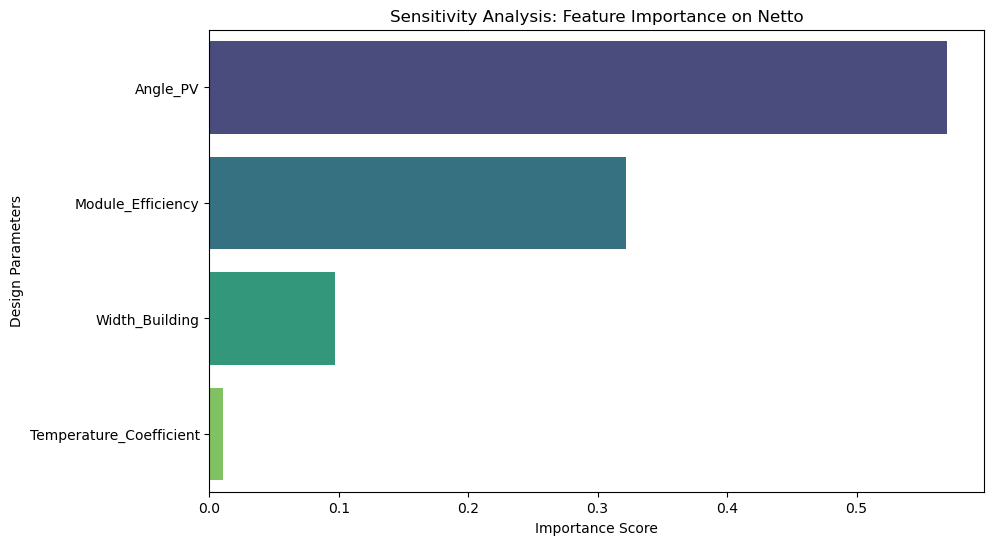

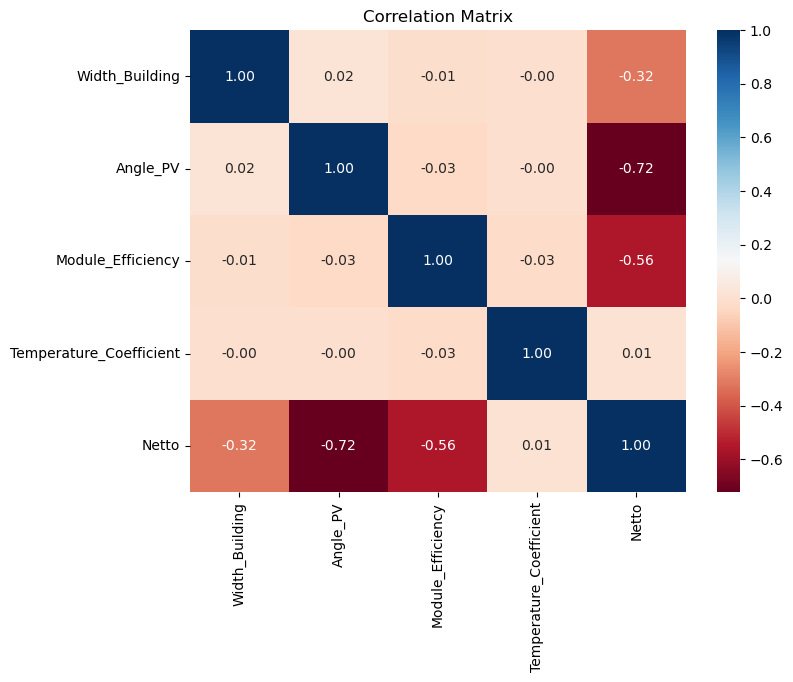

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error

# load data from SQLite database
db_path = r"E:\Research\GEG\PV_RESU.db"
conn = sqlite3.connect(db_path)
df = pd.read_sql_query("SELECT * FROM resu", conn)
conn.close()

# define features and target
features = ['Width_Building', 'Angle_PV', 'Module_Efficiency', 'Temperature_Coefficient']
target = 'Netto'

X = df[features]
y = df[target]

# train model
# split data into training and test sets (80/20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# use random forest regression 
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# evaluation
y_pred = model.predict(X_test)
print(f"model R²: {r2_score(y_test, y_pred):.4f}")
print(f"MAE: {mean_absolute_error(y_test, y_pred):.2f}")

# importance ranking of features
importances = model.feature_importances_
indices = np.argsort(importances)[::-1]

# visualization 
plt.figure(figsize=(10, 6))
sns.barplot(x=importances[indices], y=[features[i] for i in indices], palette='viridis')
plt.title('Sensitivity Analysis: Feature Importance on Netto')
plt.xlabel('Importance Score')
plt.ylabel('Design Parameters')
plt.show()

# correlation matrix (supplementary analysis) 
plt.figure(figsize=(8, 6))
sns.heatmap(df[features + [target]].corr(), annot=True, cmap='RdBu', fmt=".2f")
plt.title('Correlation Matrix')
plt.show()

SHAP

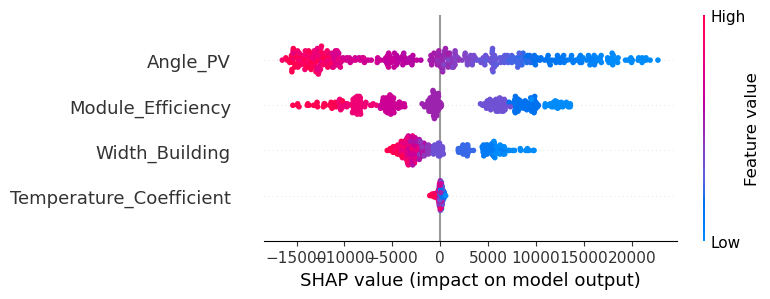

In [4]:
import shap

# 1. create SHAP explainer for the trained model
explainer = shap.TreeExplainer(model)

# 2. calculate SHAP values (based on your feature data X)
shap_values = explainer.shap_values(X)

# 3. plot summary of SHAP values for all features
shap.summary_plot(shap_values, X)


Sensitivity Analysis

S₁: First-order Sensitivity Index

Measures the direct contribution of a single variable to the output variation, assuming all other parameters remain fixed. It indicates how much the result changes when only this variable varies.

S_T： Measures the overall contribution of a single variable to the output variation, including both its direct effect and all interaction effects with other variables.

S_2：Measures the interaction effect between two variables, indicating how their combined variation influences the output.

_conf：Represents the uncertainty range of the sensitivity index estimation. For example, if the total-effect index ST is 0.60 and ST_conf is 0.05, the actual value is expected to lie within:0.60±0.05 meaning the estimated sensitivity index ranges from 0.55 to 0.65.

C:\Users\xushe\AppData\Local\Temp\ipykernel_10116\2335261508.py:37: DeprecationWarning: `salib.sample.saltelli` will be removed in SALib 1.5. Please use `salib.sample.sobol`
  param_values = saltelli.sample(problem, 1024)
c:\Users\xushe\anaconda3\envs\gh_py\lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestRegressor was fitted with feature names
  warnings.warn(


                               ST   ST_conf
Width_Building           0.085826  0.008610
Angle_PV                 0.601764  0.056945
Module_Efficiency        0.329563  0.030110
Temperature_Coefficient  0.000656  0.000129
                               S1   S1_conf
Width_Building           0.084022  0.027148
Angle_PV                 0.589734  0.062202
Module_Efficiency        0.313987  0.047332
Temperature_Coefficient  0.000481  0.002437
                                                    S2   S2_conf
(Width_Building, Angle_PV)                   -0.000635  0.042742
(Width_Building, Module_Efficiency)          -0.006478  0.041878
(Width_Building, Temperature_Coefficient)    -0.004766  0.033828
(Angle_PV, Module_Efficiency)                 0.011168  0.088379
(Angle_PV, Temperature_Coefficient)           0.001365  0.063388
(Module_Efficiency, Temperature_Coefficient)  0.000183  0.068631


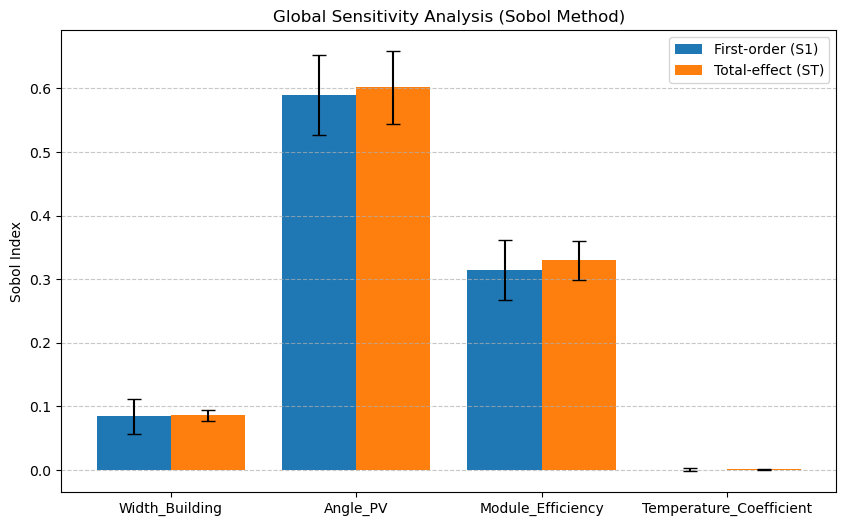

In [ ]:
import sqlite3
import pandas as pd
import numpy as np
from SALib.sample import saltelli
from SALib.analyze import sobol
from sklearn.ensemble import RandomForestRegressor
import matplotlib.pyplot as plt

# load data from database
db_path = r"E:\Research\GEG\PV_RESU.db"
conn = sqlite3.connect(db_path)
df = pd.read_sql_query("SELECT * FROM resu", conn)
conn.close()

features = ['Width_Building', 'Angle_PV', 'Module_Efficiency', 'Temperature_Coefficient']
X = df[features]
y = df['Netto']

#  RandomForestRegressor (Surrogate Model)
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X, y)

# define the parameter space for Sobol sensitivity analysis
problem = {
    'num_vars': 4,
    'names': features,
    'bounds': [
        [df['Width_Building'].min(), df['Width_Building'].max()],
        [df['Angle_PV'].min(), df['Angle_PV'].max()],
        [df['Module_Efficiency'].min(), df['Module_Efficiency'].max()],
        [df['Temperature_Coefficient'].min(), df['Temperature_Coefficient'].max()]
    ]
}

# Sampling using Saltelli's method
param_values = saltelli.sample(problem, 1024) 

# predictions using the surrogate model
Y = model.predict(param_values)

# Sobol analysis 
Si = sobol.analyze(problem, Y, print_to_console=True)

# Visualization for Sobol analysis results
# retrieve first/total order indices and their confidence intervals
S1 = Si['S1']
ST = Si['ST']
err1 = Si['S1_conf']
errT = Si['ST_conf']

x_axis = np.arange(len(features))

plt.figure(figsize=(10, 6))
plt.bar(x_axis - 0.2, S1, width=0.4, label='First-order (S1)', yerr=err1, capsize=5)
plt.bar(x_axis + 0.2, ST, width=0.4, label='Total-effect (ST)', yerr=errT, capsize=5)

plt.xticks(x_axis, features)
plt.ylabel('Sobol Index')
plt.title('Global Sensitivity Analysis (Sobol Method)')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Uncertainty analysis 

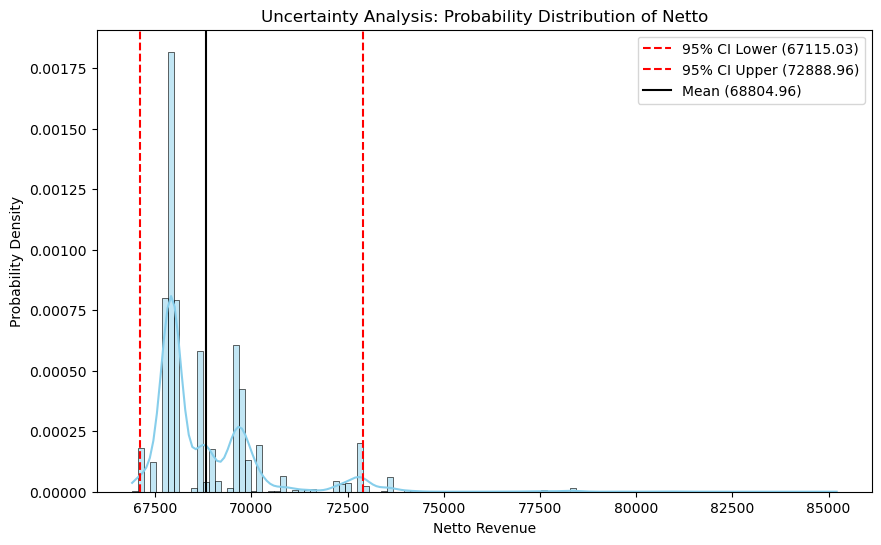

Predicted Mean Value: 68804.96
95% Confidence Interval: [67115.03, 72888.96]
Coefficient of Variation (CV): 0.0226


In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Simulate uncertainty around a given design
# Given：Width=15, Angle=35, Eff=0.20, TempCoeff=-0.004
base_design = np.array([15, 35, 0.20, -0.004])

n_simulations = 10000

# Generate uncertain input variables using normal distributions
# Width variation: ±0.1 m
# Installation angle error: ±2 degrees
# Efficiency variation: ±0.01
# Temperature coefficient variation: 5%
uncertainty_input = pd.DataFrame({
    'Width_Building': np.random.normal(15, 0.1, n_simulations),
    'Angle_PV': np.random.normal(35, 2.0, n_simulations),
    'Module_Efficiency': np.random.normal(0.20, 0.01, n_simulations),
    'Temperature_Coefficient': np.random.normal(-0.004, 0.0002, n_simulations)
})

#  Predict Output Distribution Using the Surrogate Model
y_pred_dist = model.predict(uncertainty_input)

# Visualize Uncertainty Distribution
plt.figure(figsize=(10, 6))
sns.histplot(y_pred_dist, kde=True, color='skyblue', stat="density")

# Calculate 95% Confidence Interval
ci_lower = np.percentile(y_pred_dist, 2.5)
ci_upper = np.percentile(y_pred_dist, 97.5)
mean_val = np.mean(y_pred_dist)

plt.axvline(ci_lower, color='red', linestyle='--', label=f'95% CI Lower ({ci_lower:.2f})')
plt.axvline(ci_upper, color='red', linestyle='--', label=f'95% CI Upper ({ci_upper:.2f})')
plt.axvline(mean_val, color='black', linestyle='-', label=f'Mean ({mean_val:.2f})')

plt.title('Uncertainty Analysis: Probability Distribution of Netto')
plt.xlabel('Netto Revenue')
plt.ylabel('Probability Density')
plt.legend()
plt.show()

print(f"Predicted Mean Value: {mean_val:.2f}")
print(f"95% Confidence Interval: [{ci_lower:.2f}, {ci_upper:.2f}]")
print(f"Coefficient of Variation (CV): {np.std(y_pred_dist)/mean_val:.4f}")

全域性能图谱

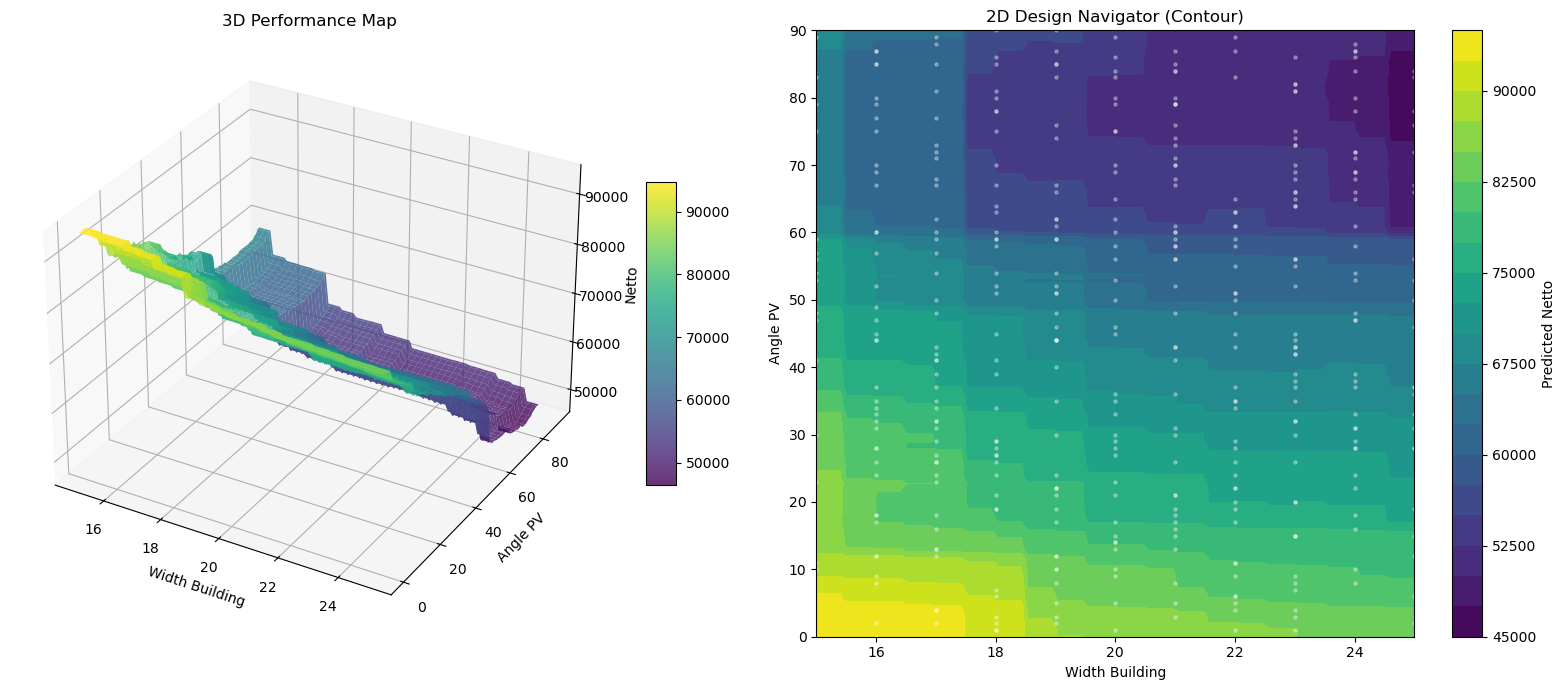

In [24]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestRegressor
from matplotlib import cm

# ===== 1. 准备数据与模型 =====
db_path = r"E:\Research\GEG\PV_RESU.db"
conn = sqlite3.connect(db_path)
df = pd.read_sql_query("SELECT * FROM resu", conn)
conn.close()

features = ['Width_Building', 'Angle_PV', 'Module_Efficiency', 'Temperature_Coefficient']
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(df[features], df['Netto'])

# ===== 2. 创建扫描网格 (全域采样) =====
# 我们想看 Width (X轴) 和 Angle (Y轴) 的交互
num_points = 100
width_axis = np.linspace(df['Width_Building'].min(), df['Width_Building'].max(), num_points)
angle_axis = np.linspace(df['Angle_PV'].min(), df['Angle_PV'].max(), num_points)
W, A = np.meshgrid(width_axis, angle_axis)

# 将其他参数固定在平均值
avg_eff = df['Module_Efficiency'].mean()
avg_temp = df['Temperature_Coefficient'].mean()

# 构建预测输入
scan_input = pd.DataFrame({
    'Width_Building': W.ravel(),
    'Angle_PV': A.ravel(),
    'Module_Efficiency': [avg_eff] * (num_points**2),
    'Temperature_Coefficient': [avg_temp] * (num_points**2)
})

# 预测 Netto
Z_values = model.predict(scan_input)
Z = Z_values.reshape(W.shape)

# ===== 3. 可视化：3D 曲面 + 等高线图 =====
fig = plt.figure(figsize=(16, 7))

# --- 左图：3D 响应曲面 ---
ax1 = fig.add_subplot(121, projection='3d')
surf = ax1.plot_surface(W, A, Z, cmap='viridis', edgecolor='none', alpha=0.8)
ax1.set_xlabel('Width Building')
ax1.set_ylabel('Angle PV')
ax1.set_zlabel('Netto')
ax1.set_title('3D Performance Map')
fig.colorbar(surf, ax=ax1, shrink=0.5, aspect=10)

# --- 右图：2D 等高线图 (设计导航图) ---
ax2 = fig.add_subplot(122)
contour = ax2.contourf(W, A, Z, levels=20, cmap='viridis')
ax2.set_xlabel('Width Building')
ax2.set_ylabel('Angle PV')
ax2.set_title('2D Design Navigator (Contour)')
clb = fig.colorbar(contour, ax=ax2)
clb.set_label('Predicted Netto')

# 可以在图上标注出原始采样点，看分布情况
ax2.scatter(df['Width_Building'], df['Angle_PV'], c='white', s=5, alpha=0.3, label='Sample Points')

plt.tight_layout()
plt.show()

parallel coordinate

In [ ]:
import sqlite3
import pandas as pd
import plotly.express as px

# ===== 1. 加载数据 =====
db_path = r"E:\Research\GEG\PV_RESU.db"
conn = sqlite3.connect(db_path)
df = pd.read_sql_query("SELECT * FROM resu", conn)
conn.close()

# 为了让图表更清晰，我们可以给列名换成更易读的标签
# 如果 ID 列对分析没意义，可以剔除
plot_df = df[['Width_Building', 'Angle_PV', 'Module_Efficiency', 
              'Temperature_Coefficient', 'Netto']]

# ===== 3. 创建平行坐标图 =====
fig = px.parallel_coordinates(
    plot_df, 
    color="Netto",  # 以 Netto 作为颜色映射，一眼分出好坏
    labels={
        "Width_Building": "Width (m)",
        "Angle_PV": "Angle (°)",
        "Module_Efficiency": "Eff",
        "Temperature_Coefficient": "Temp Coeff",        
        "Netto": "Net Income"
    },
    color_continuous_scale=px.colors.sequential.Viridis, # 使用 Viridis 色带
    title="PV Performance Parallel Coordinates Analysis"
)

# 显示图表
fig.show()